In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('D:/SIH/Dataset/ner_combined_dataset.csv')

print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (2000, 32)

Columns:
['latitude', 'longitude', 'state', 'district', 'elevation_m', 'slope_deg', 'aspect_deg', 'plan_curvature', 'profile_curvature', 'tri', 'annual_rainfall_mm', 'monsoon_rainfall_mm', 'max_daily_rainfall_mm', 'soil_clay_pct', 'soil_sand_pct', 'soil_silt_pct', 'soil_organic_carbon_pct', 'soil_bulk_density', 'soil_moisture_pct', 'land_cover', 'ndvi', 'distance_to_road_km', 'road_density_km_per_km2', 'distance_to_river_km', 'distance_to_fault_km', 'seismic_zone', 'population_density_per_km2', 'historical_landslides_5km_10yr', 'event_date', 'landslide_trigger', 'landslide_size', 'label']

First 5 rows:


,latitude,longitude,state,district,elevation_m,slope_deg,aspect_deg,plan_curvature,profile_curvature,tri,...,road_density_km_per_km2,distance_to_river_km,distance_to_fault_km,seismic_zone,population_density_per_km2,historical_landslides_5km_10yr,event_date,landslide_trigger,landslide_size,label
0,25.005450,96.369118,Nagaland,Tuensang,771.646100,8.373468,127.874425,1.251669,-0.521151,36.573042,...,0.376292,1.627990,9.486869,V,83.654987,1,NaN,NaN,NaN,0
1,24.074429,88.918396,Manipur,Tamenglong,1528.892223,24.817330,165.204659,1.216087,3.333976,68.113968,...,0.662478,3.687229,0.826782,IV,86.910772,2,NaN,NaN,NaN,0
2,24.780858,93.532680,Manipur,Churachandpur,1146.208796,26.588032,334.996792,-0.072269,-1.119757,72.802379,...,1.763325,7.434329,4.129145,V,290.966967,2,06/07/2010 12:00:00 AM,rain,medium,1
3,24.027678,91.409653,Tripura,West Tripura,1395.550022,17.751897,240.340667,-2.710512,0.494975,45.911973,...,1.105033,3.414764,13.036041,V,316.705653,6,05/08/2013 12:00:00 AM,rain,medium,1
4,28.365400,89.336230,Mizoram,Champhai,1210.677275,10.337031,244.810340,-1.075483,0.913262,35.692124,...,1.625462,0.349092,3.415605,IV,114.373584,0,NaN,NaN,NaN,0


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   latitude                        2000 non-null   float64
 1   longitude                       2000 non-null   float64
 2   state                           2000 non-null   object 
 3   district                        2000 non-null   object 
 4   elevation_m                     2000 non-null   float64
 5   slope_deg                       2000 non-null   float64
 6   aspect_deg                      2000 non-null   float64
 7   plan_curvature                  2000 non-null   float64
 8   profile_curvature               2000 non-null   float64
 9   tri                             2000 non-null   float64
 10  annual_rainfall_mm              2000 non-null   float64
 11  monsoon_rainfall_mm             2000 non-null   float64
 12  max_daily_rainfall_mm           20

In [18]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
latitude,2000.0,NaN,NaN,NaN,25.611722,1.999487,21.503812,24.119379,25.643607,27.157691,29.494636
longitude,2000.0,NaN,NaN,NaN,92.76558,2.488764,88.005488,90.844765,92.899441,94.554716,97.497905
state,2000,8,Assam,322,NaN,NaN,NaN,NaN,NaN,NaN,NaN
district,2000,37,North Sikkim,69,NaN,NaN,NaN,NaN,NaN,NaN,NaN
elevation_m,2000.0,NaN,NaN,NaN,1278.256403,807.871989,60.641993,665.050283,1103.139649,1704.408186,5500.0
slope_deg,2000.0,NaN,NaN,NaN,22.347525,11.740804,0.0,14.094697,21.511307,29.68134,70.251411
aspect_deg,2000.0,NaN,NaN,NaN,182.478853,102.766345,0.107018,93.933839,186.655016,271.602226,359.736282
plan_curvature,2000.0,NaN,NaN,NaN,-0.26605,2.040311,-7.466661,-1.60696,-0.229922,1.084403,6.403549
profile_curvature,2000.0,NaN,NaN,NaN,-0.12895,1.541353,-6.640968,-1.149002,-0.090367,0.913579,5.747567
tri,2000.0,NaN,NaN,NaN,79.063756,44.318846,0.0,47.041067,74.878016,106.704244,292.098784


In [19]:
missing = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
})

missing = missing.sort_values(
    by='Missing_Count',
    ascending=False
)

display(missing)

,Missing_Count,Missing_Percentage
event_date,1300,65.0
landslide_trigger,1300,65.0
landslide_size,1300,65.0
latitude,0,0.0
elevation_m,0,0.0
longitude,0,0.0
state,0,0.0
district,0,0.0
profile_curvature,0,0.0
tri,0,0.0


In [20]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [21]:
print(df['label'].value_counts())

print("\nTarget percentage:")
print(df['label'].value_counts(normalize=True) * 100)

label
0    1300
1     700
Name: count, dtype: int64

Target percentage:
label
0    65.0
1    35.0
Name: proportion, dtype: float64


In [22]:
print("States:")
print(df['state'].value_counts())

States:
state
Assam                322
Nagaland             311
Manipur              284
Arunachal Pradesh    237
Sikkim               233
Meghalaya            228
Mizoram              206
Tripura              179
Name: count, dtype: int64


In [23]:
print("Districts:")
print(df['district'].nunique())

Districts:
37


In [24]:
print("Latitude range:")
print(df['latitude'].min(), "to", df['latitude'].max())

print("\nLongitude range:")
print(df['longitude'].min(), "to", df['longitude'].max())

Latitude range:
21.50381192112816 to 29.494635560560692

Longitude range:
88.00548755582258 to 97.49790475154116


In [25]:
print("Invalid latitude:")
print(df[(df['latitude'] < -90) | (df['latitude'] > 90)])

print("Invalid longitude:")
print(df[(df['longitude'] < -180) | (df['longitude'] > 180)])

Invalid latitude:
Empty DataFrame
Columns: [latitude, longitude, state, district, elevation_m, slope_deg, aspect_deg, plan_curvature, profile_curvature, tri, annual_rainfall_mm, monsoon_rainfall_mm, max_daily_rainfall_mm, soil_clay_pct, soil_sand_pct, soil_silt_pct, soil_organic_carbon_pct, soil_bulk_density, soil_moisture_pct, land_cover, ndvi, distance_to_road_km, road_density_km_per_km2, distance_to_river_km, distance_to_fault_km, seismic_zone, population_density_per_km2, historical_landslides_5km_10yr, event_date, landslide_trigger, landslide_size, label]
Index: []

[0 rows x 32 columns]
Invalid longitude:
Empty DataFrame
Columns: [latitude, longitude, state, district, elevation_m, slope_deg, aspect_deg, plan_curvature, profile_curvature, tri, annual_rainfall_mm, monsoon_rainfall_mm, max_daily_rainfall_mm, soil_clay_pct, soil_sand_pct, soil_silt_pct, soil_organic_carbon_pct, soil_bulk_density, soil_moisture_pct, land_cover, ndvi, distance_to_road_km, road_density_km_per_km2, distan

In [26]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    print(
        f"{col}: "
        f"min={df[col].min():.3f}, "
        f"max={df[col].max():.3f}, "
        f"mean={df[col].mean():.3f}"
    )

latitude: min=21.504, max=29.495, mean=25.612
longitude: min=88.005, max=97.498, mean=92.766
elevation_m: min=60.642, max=5500.000, mean=1278.256
slope_deg: min=0.000, max=70.251, mean=22.348
aspect_deg: min=0.107, max=359.736, mean=182.479
plan_curvature: min=-7.467, max=6.404, mean=-0.266
profile_curvature: min=-6.641, max=5.748, mean=-0.129
tri: min=0.000, max=292.099, mean=79.064
annual_rainfall_mm: min=1450.951, max=7585.118, mean=3482.328
monsoon_rainfall_mm: min=1010.679, max=5730.464, mean=2616.038
max_daily_rainfall_mm: min=22.547, max=238.029, mean=79.469
soil_clay_pct: min=5.000, max=55.683, mean=29.491
soil_sand_pct: min=5.000, max=69.451, mean=34.643
soil_silt_pct: min=5.000, max=70.000, mean=35.874
soil_organic_carbon_pct: min=0.200, max=11.090, mean=2.386
soil_bulk_density: min=0.900, max=1.700, mean=1.297
soil_moisture_pct: min=5.000, max=60.000, mean=35.466
ndvi: min=-0.100, max=0.950, mean=0.494
distance_to_road_km: min=0.010, max=21.927, mean=2.376
road_density_km_pe

In [27]:
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (2000, 32)

Columns:
['latitude', 'longitude', 'state', 'district', 'elevation_m', 'slope_deg', 'aspect_deg', 'plan_curvature', 'profile_curvature', 'tri', 'annual_rainfall_mm', 'monsoon_rainfall_mm', 'max_daily_rainfall_mm', 'soil_clay_pct', 'soil_sand_pct', 'soil_silt_pct', 'soil_organic_carbon_pct', 'soil_bulk_density', 'soil_moisture_pct', 'land_cover', 'ndvi', 'distance_to_road_km', 'road_density_km_per_km2', 'distance_to_river_km', 'distance_to_fault_km', 'seismic_zone', 'population_density_per_km2', 'historical_landslides_5km_10yr', 'event_date', 'landslide_trigger', 'landslide_size', 'label']


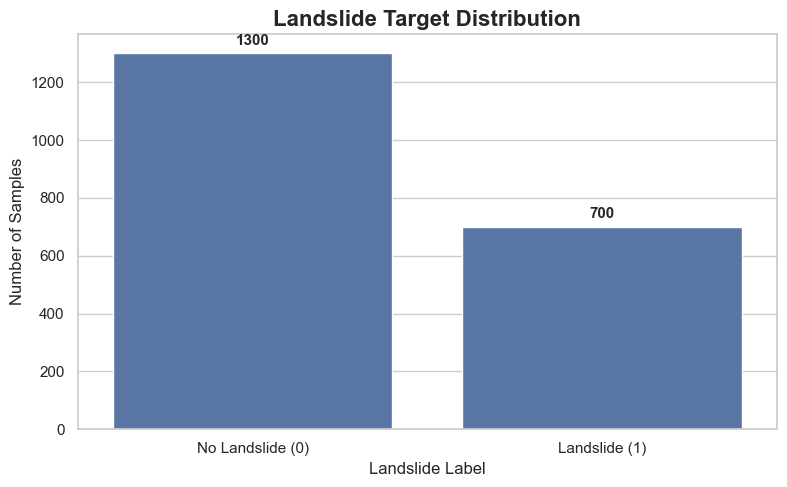

In [28]:
label_counts = df["label"].value_counts().sort_index()

plt.figure(figsize=(8, 5))

ax = sns.barplot(
    x=label_counts.index,
    y=label_counts.values
)

plt.title("Landslide Target Distribution", fontsize=16, fontweight="bold")
plt.xlabel("Landslide Label")
plt.ylabel("Number of Samples")
plt.xticks([0, 1], ["No Landslide (0)", "Landslide (1)"])

for i, value in enumerate(label_counts.values):
    ax.text(i, value + 30, str(value), ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

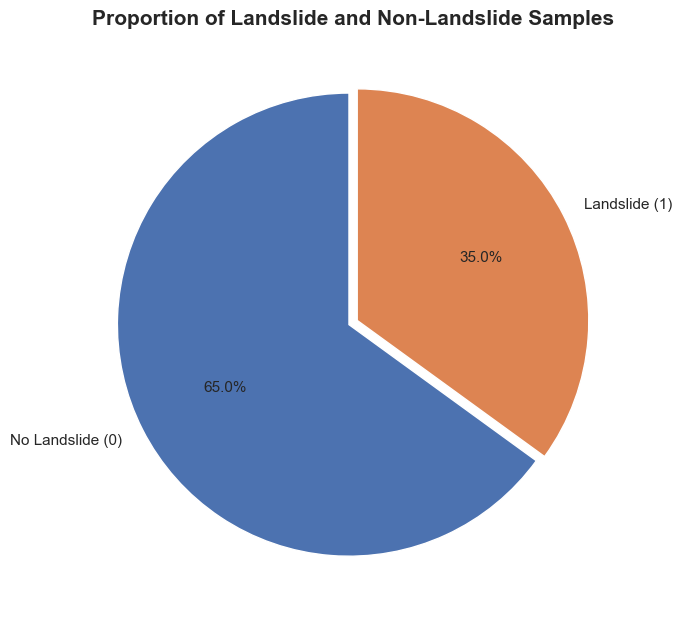

In [29]:
label_counts = df["label"].value_counts().sort_index()

plt.figure(figsize=(7, 7))

plt.pie(
    label_counts.values,
    labels=["No Landslide (0)", "Landslide (1)"],
    autopct="%1.1f%%",
    startangle=90,
    explode=[0.02, 0.02]
)

plt.title(
    "Proportion of Landslide and Non-Landslide Samples",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

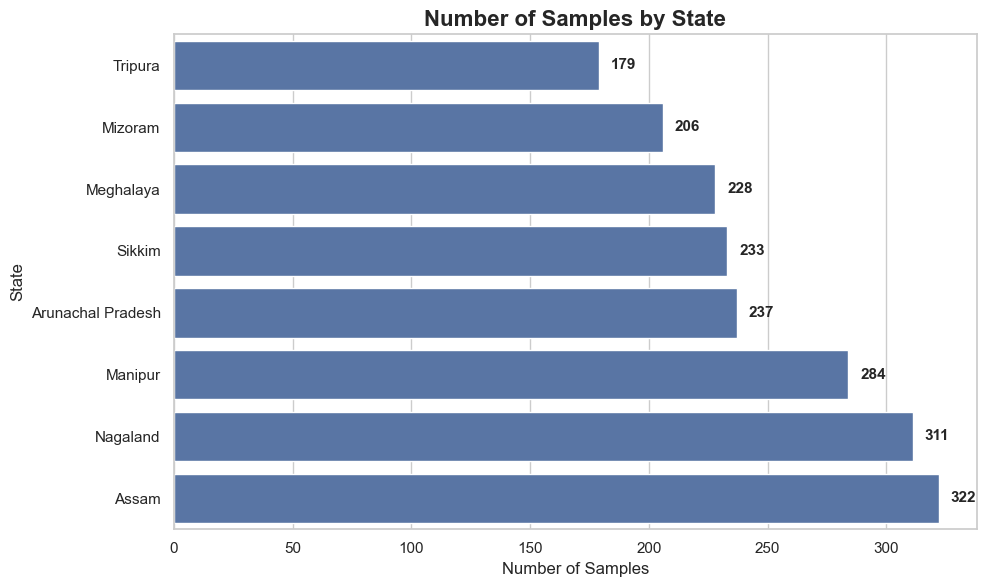

In [30]:
state_counts = df["state"].value_counts().sort_values(ascending=True)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=state_counts.values,
    y=state_counts.index
)

plt.title(
    "Number of Samples by State",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Samples")
plt.ylabel("State")

for i, value in enumerate(state_counts.values):
    ax.text(value + 5, i, str(value), va="center", fontweight="bold")

plt.tight_layout()
plt.show()

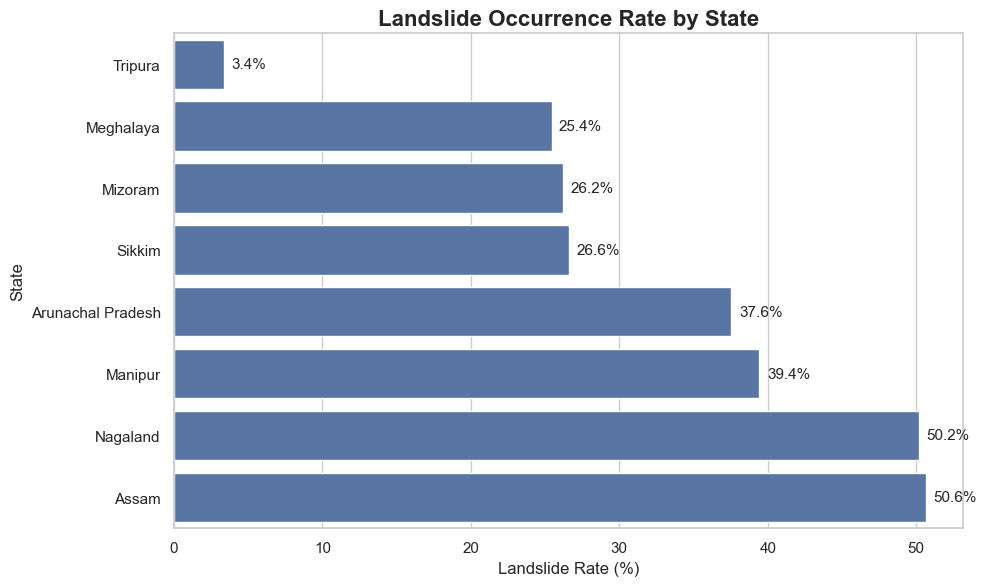

In [31]:
state_landslide_rate = (
    df.groupby("state")["label"]
      .mean()
      .sort_values(ascending=True) * 100
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=state_landslide_rate.values,
    y=state_landslide_rate.index
)

plt.title(
    "Landslide Occurrence Rate by State",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Landslide Rate (%)")
plt.ylabel("State")

for i, value in enumerate(state_landslide_rate.values):
    ax.text(
        value + 0.5,
        i,
        f"{value:.1f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

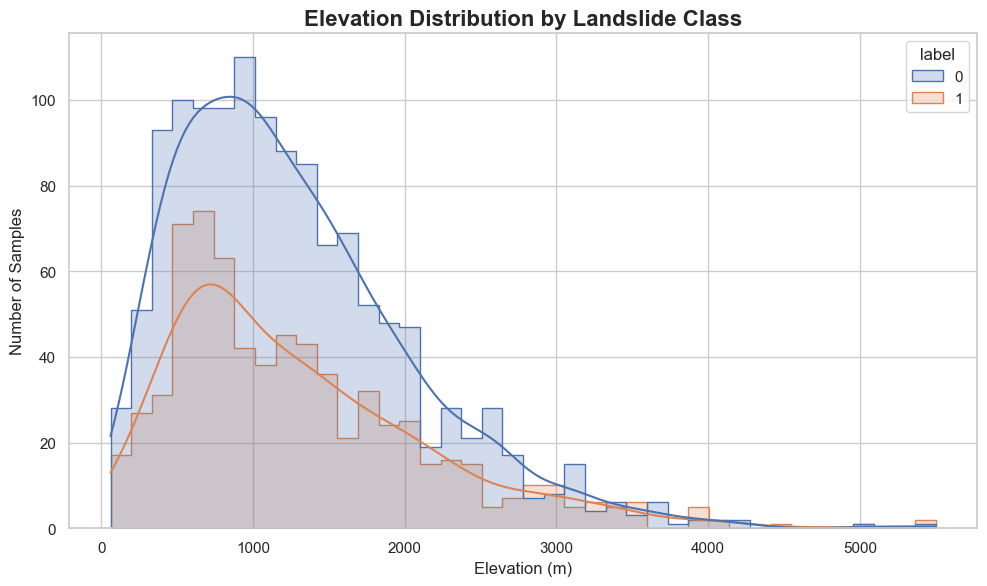

In [32]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="elevation_m",
    hue="label",
    bins=40,
    kde=True,
    element="step"
)

plt.title(
    "Elevation Distribution by Landslide Class",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Elevation (m)")
plt.ylabel("Number of Samples")

plt.tight_layout()
plt.show()

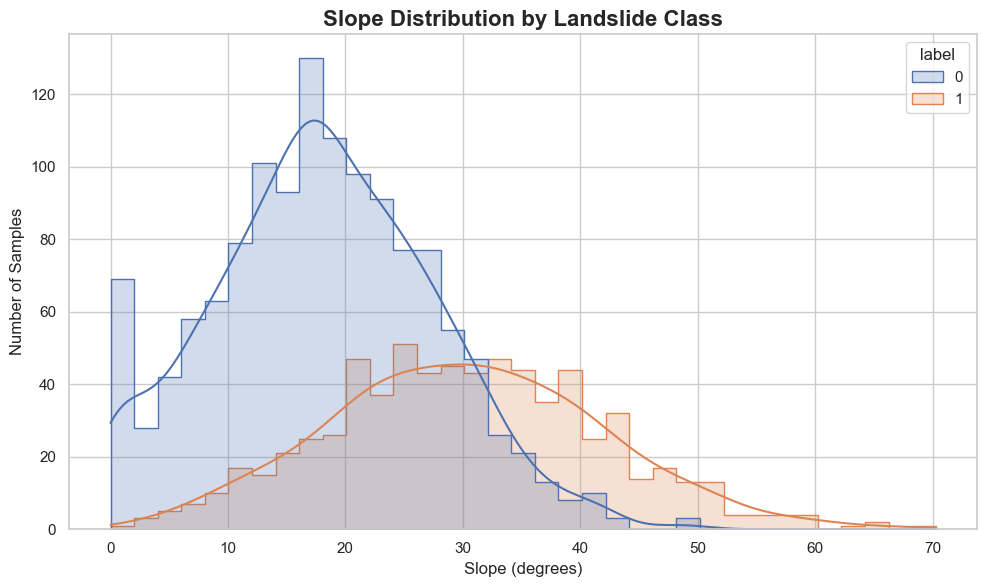

In [33]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="slope_deg",
    hue="label",
    bins=35,
    kde=True,
    element="step"
)

plt.title(
    "Slope Distribution by Landslide Class",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Slope (degrees)")
plt.ylabel("Number of Samples")

plt.tight_layout()
plt.show()

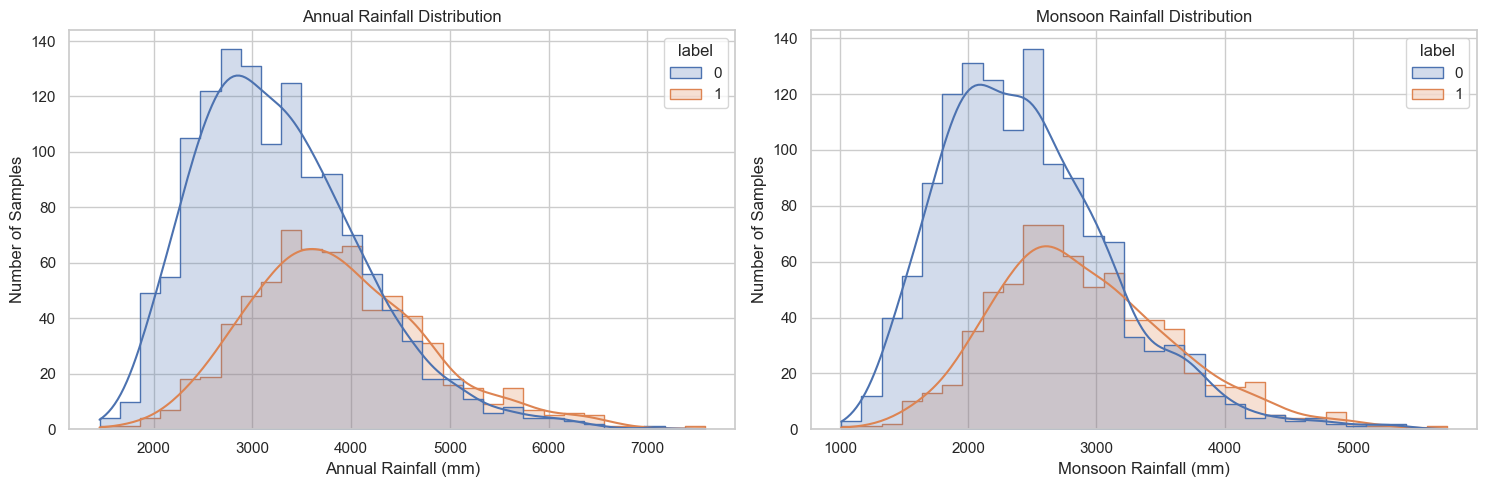

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(
    data=df,
    x="annual_rainfall_mm",
    hue="label",
    bins=30,
    kde=True,
    element="step",
    ax=axes[0]
)

axes[0].set_title("Annual Rainfall Distribution")
axes[0].set_xlabel("Annual Rainfall (mm)")
axes[0].set_ylabel("Number of Samples")


sns.histplot(
    data=df,
    x="monsoon_rainfall_mm",
    hue="label",
    bins=30,
    kde=True,
    element="step",
    ax=axes[1]
)

axes[1].set_title("Monsoon Rainfall Distribution")
axes[1].set_xlabel("Monsoon Rainfall (mm)")
axes[1].set_ylabel("Number of Samples")

plt.tight_layout()
plt.show()

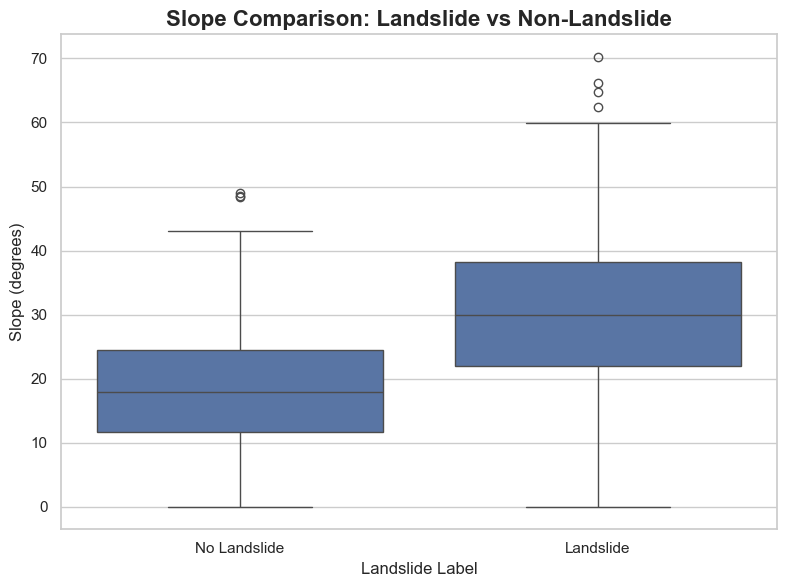

In [35]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="label",
    y="slope_deg"
)

plt.title(
    "Slope Comparison: Landslide vs Non-Landslide",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Landslide Label")
plt.ylabel("Slope (degrees)")
plt.xticks([0, 1], ["No Landslide", "Landslide"])

plt.tight_layout()
plt.show()

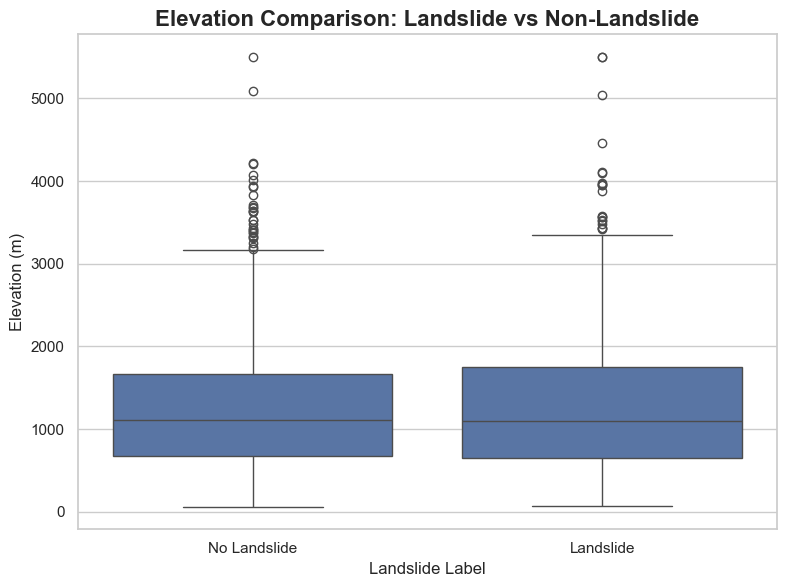

In [36]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df,
    x="label",
    y="elevation_m"
)

plt.title(
    "Elevation Comparison: Landslide vs Non-Landslide",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Landslide Label")
plt.ylabel("Elevation (m)")
plt.xticks([0, 1], ["No Landslide", "Landslide"])

plt.tight_layout()
plt.show()

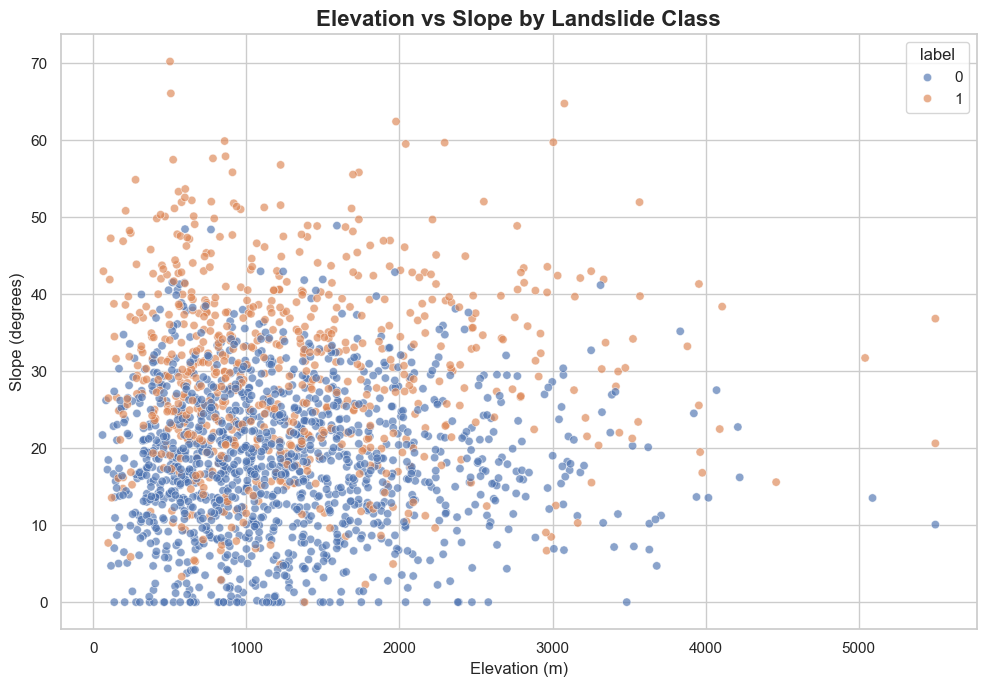

In [37]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="elevation_m",
    y="slope_deg",
    hue="label",
    alpha=0.65
)

plt.title(
    "Elevation vs Slope by Landslide Class",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Elevation (m)")
plt.ylabel("Slope (degrees)")

plt.tight_layout()
plt.show()

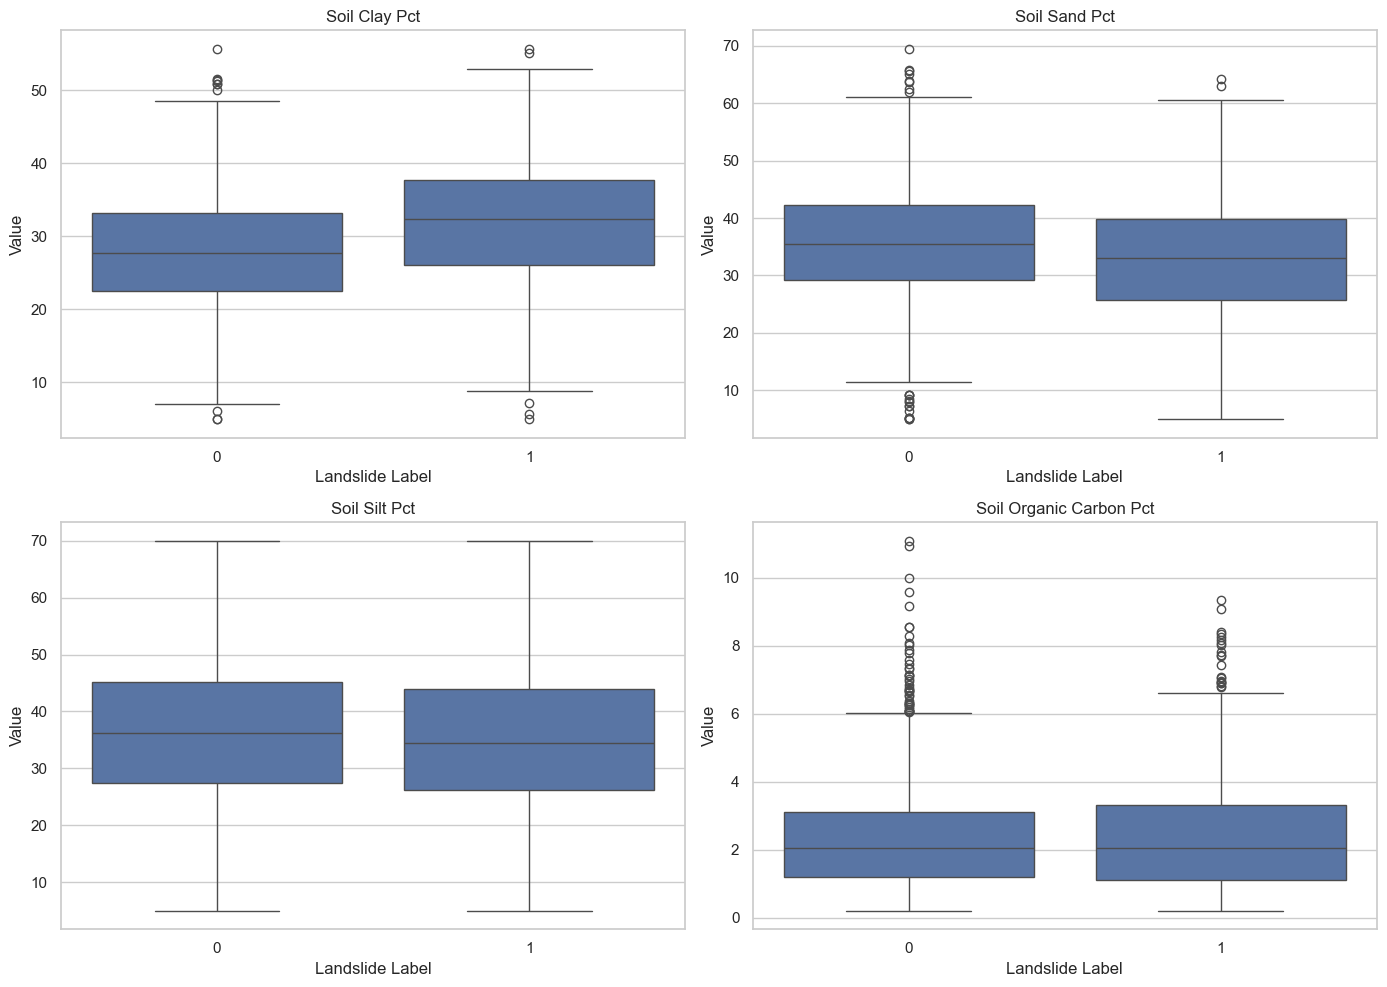

In [38]:
soil_cols = [
    "soil_clay_pct",
    "soil_sand_pct",
    "soil_silt_pct",
    "soil_organic_carbon_pct"
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flatten(), soil_cols):

    sns.boxplot(
        data=df,
        x="label",
        y=col,
        ax=ax
    )

    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel("Landslide Label")
    ax.set_ylabel("Value")

plt.tight_layout()
plt.show()

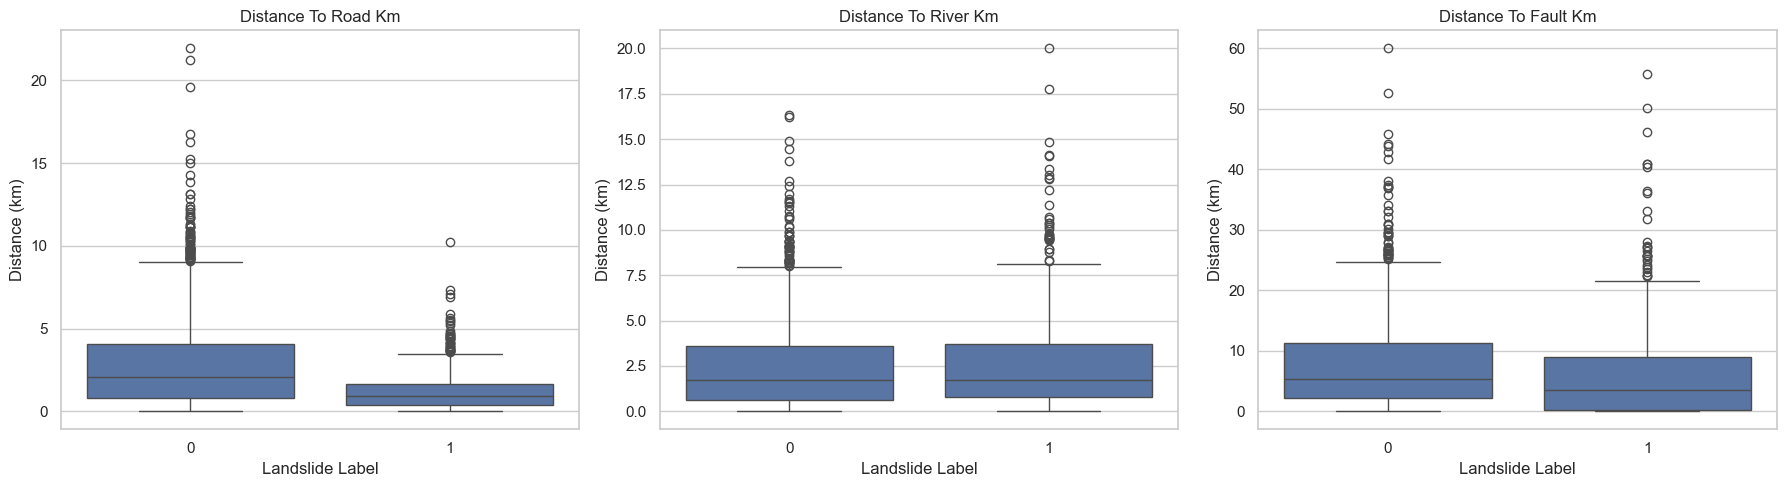

In [39]:
distance_cols = [
    "distance_to_road_km",
    "distance_to_river_km",
    "distance_to_fault_km"
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, distance_cols):

    sns.boxplot(
        data=df,
        x="label",
        y=col,
        ax=ax
    )

    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel("Landslide Label")
    ax.set_ylabel("Distance (km)")

plt.tight_layout()
plt.show()

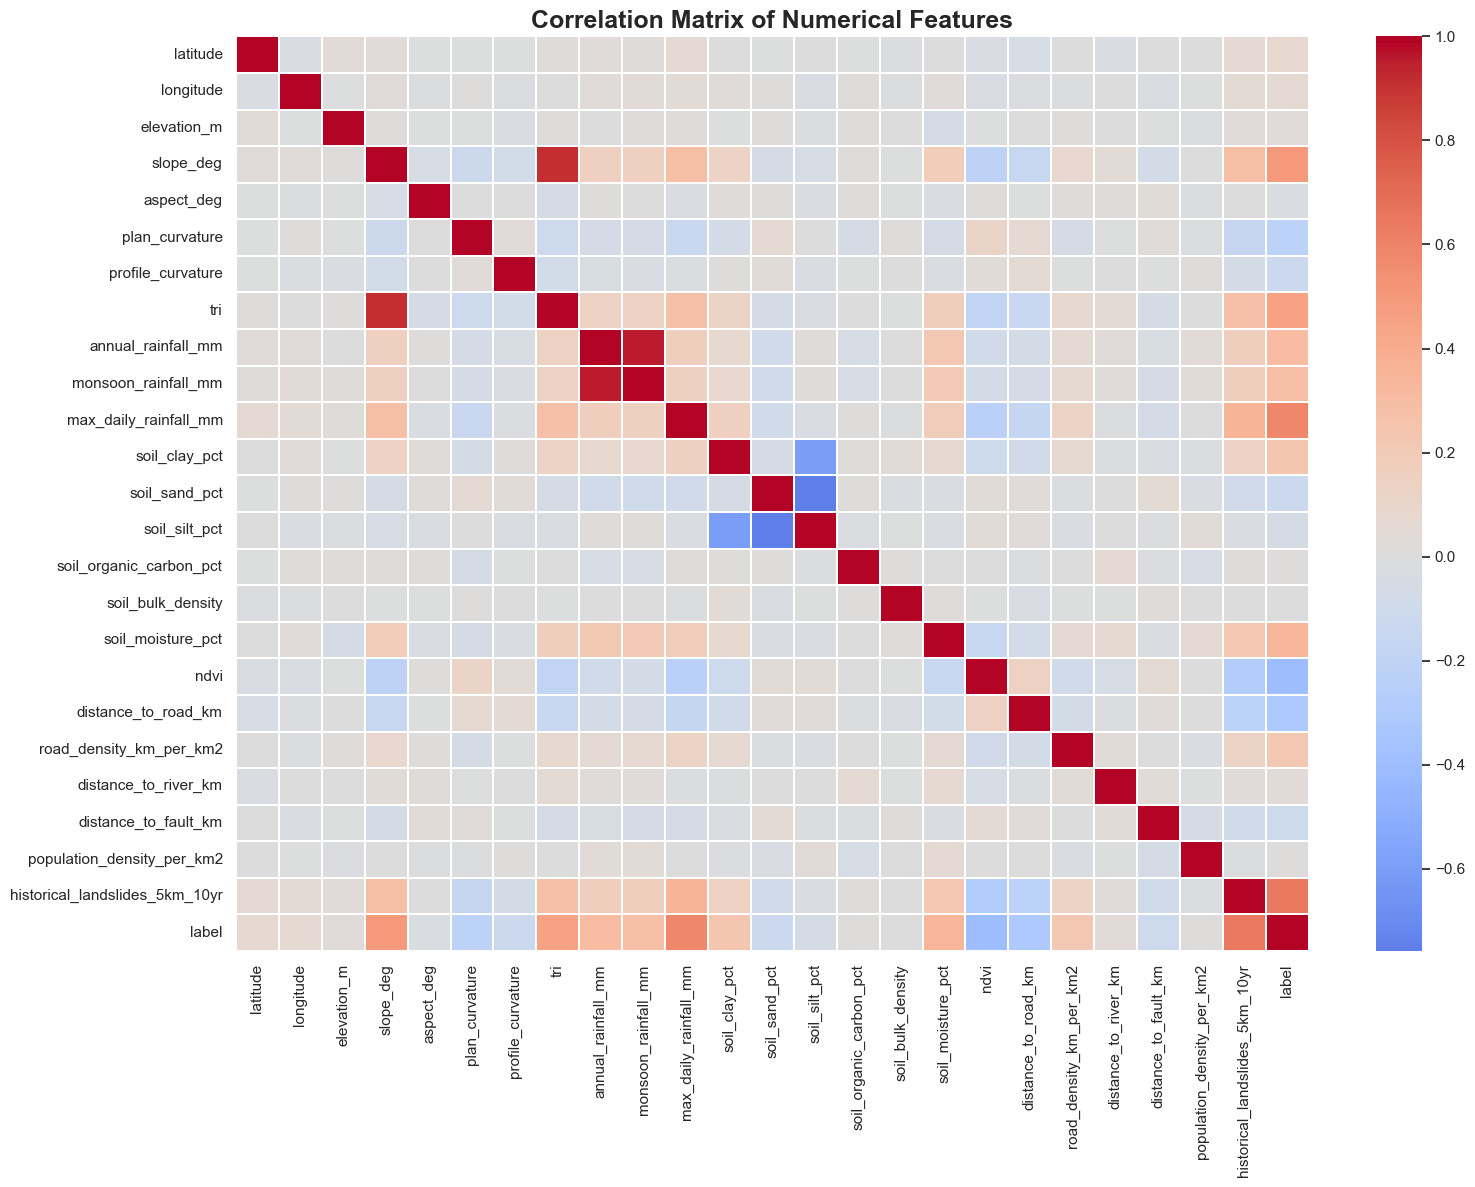

In [40]:
numeric_cols = df.select_dtypes(include=np.number).columns

corr = df[numeric_cols].corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    linewidths=0.3
)

plt.title(
    "Correlation Matrix of Numerical Features",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

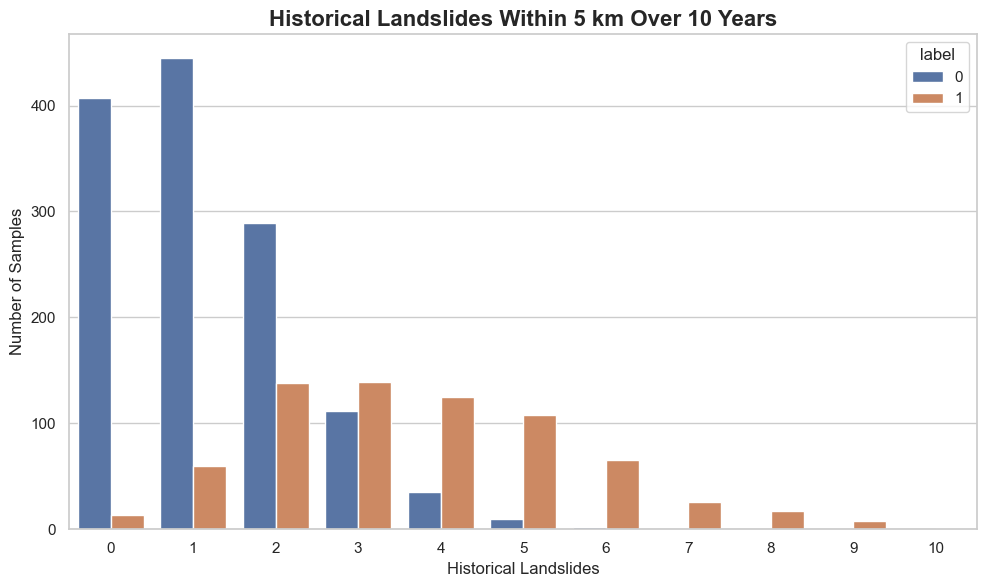

In [41]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="historical_landslides_5km_10yr",
    hue="label"
)

plt.title(
    "Historical Landslides Within 5 km Over 10 Years",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Historical Landslides")
plt.ylabel("Number of Samples")

plt.tight_layout()
plt.show()

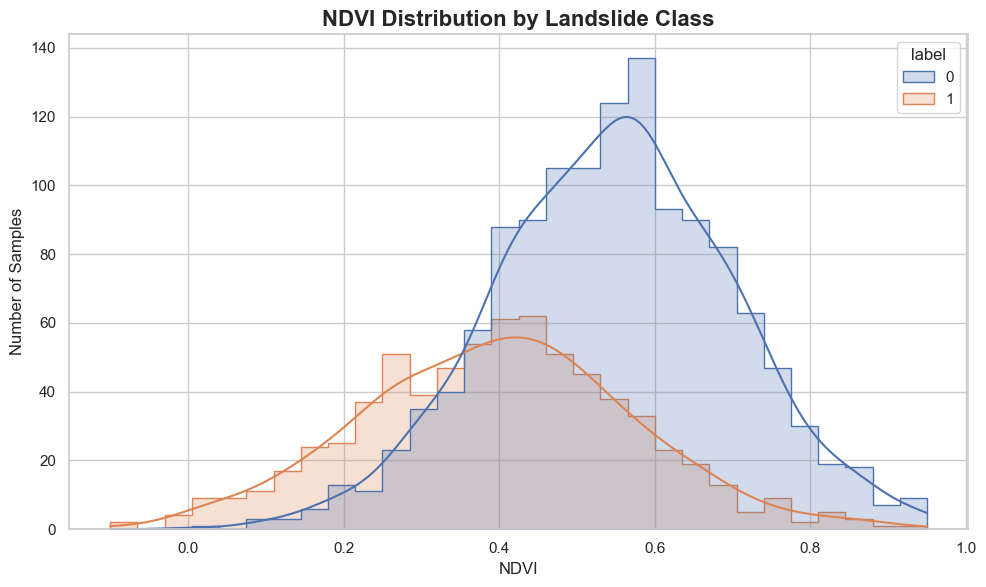

In [42]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="ndvi",
    hue="label",
    bins=30,
    kde=True,
    element="step"
)

plt.title(
    "NDVI Distribution by Landslide Class",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("NDVI")
plt.ylabel("Number of Samples")

plt.tight_layout()
plt.show()

In [43]:
state_summary = df.groupby('state').agg(
    records=('state', 'size'),

    landslides=('label', 'sum'),
    landslide_rate=('label', 'mean'),

    avg_elevation=('elevation_m', 'mean'),
    avg_slope=('slope_deg', 'mean'),

    avg_annual_rainfall=('annual_rainfall_mm', 'mean'),
    avg_monsoon_rainfall=('monsoon_rainfall_mm', 'mean'),

    avg_clay=('soil_clay_pct', 'mean'),
    avg_sand=('soil_sand_pct', 'mean'),
    avg_silt=('soil_silt_pct', 'mean'),

    avg_soil_moisture=('soil_moisture_pct', 'mean'),
    avg_ndvi=('ndvi', 'mean'),

    avg_distance_road=('distance_to_road_km', 'mean'),
    avg_distance_river=('distance_to_river_km', 'mean'),
    avg_distance_fault=('distance_to_fault_km', 'mean'),

    avg_population_density=('population_density_per_km2', 'mean'),

    avg_historical_landslides=('historical_landslides_5km_10yr', 'mean')
)

state_summary['landslide_rate'] *= 100

state_summary = state_summary.sort_values(
    'landslide_rate',
    ascending=False
)

display(state_summary)

,records,landslides,landslide_rate,avg_elevation,avg_slope,avg_annual_rainfall,avg_monsoon_rainfall,avg_clay,avg_sand,avg_silt,avg_soil_moisture,avg_ndvi,avg_distance_road,avg_distance_river,avg_distance_fault,avg_population_density,avg_historical_landslides
state,,,,,,,,,,,,,,,,,
Assam,322,163,50.621118,1260.300713,24.671819,3644.260967,2722.724846,30.779531,34.431156,34.793207,36.616440,0.483794,2.012691,2.690943,6.991167,174.152087,2.409938
Nagaland,311,156,50.160772,1290.242167,24.278596,3488.680676,2606.168667,30.060953,33.607143,36.361329,37.311381,0.466319,2.104202,2.659144,6.562247,176.814018,2.549839
Manipur,284,112,39.436620,1290.398164,22.823061,3558.097371,2681.068782,29.160102,34.119919,36.673140,35.455578,0.493849,2.440276,2.528992,7.078796,161.590367,2.154930
Arunachal Pradesh,237,89,37.552743,1338.454503,22.506747,3465.165772,2611.688505,29.209963,35.551012,35.204750,35.756040,0.474593,2.385897,2.670144,7.277625,161.343978,2.105485
Sikkim,233,62,26.609442,1266.416232,21.291649,3373.249659,2518.174451,28.806418,35.283326,35.953696,33.546470,0.511302,2.580798,2.329542,7.474009,156.647536,1.759657
Mizoram,206,54,26.213592,1244.841941,20.832203,3541.720070,2706.634518,29.266156,34.866760,35.867084,34.817497,0.514377,2.781759,2.448893,7.284191,171.406097,1.907767
Meghalaya,228,58,25.438596,1262.841190,21.885627,3382.966326,2553.091391,29.606906,34.583062,35.829771,35.200054,0.494602,2.429008,2.494638,7.328204,188.070134,1.951754
Tripura,179,6,3.351955,1264.266218,17.552637,3282.692564,2447.150119,28.080791,35.438464,36.545498,33.402403,0.539099,2.580075,2.497888,8.191246,183.291463,1.206704


In [44]:
model_df = df.copy()

print("Original shape:", model_df.shape)

Original shape: (2000, 32)


In [45]:
X = model_df.drop(columns=['label'])
y = model_df['label']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2000, 31)
y shape: (2000,)


In [46]:
print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['latitude', 'longitude', 'state', 'district', 'elevation_m', 'slope_deg', 'aspect_deg', 'plan_curvature', 'profile_curvature', 'tri', 'annual_rainfall_mm', 'monsoon_rainfall_mm', 'max_daily_rainfall_mm', 'soil_clay_pct', 'soil_sand_pct', 'soil_silt_pct', 'soil_organic_carbon_pct', 'soil_bulk_density', 'soil_moisture_pct', 'land_cover', 'ndvi', 'distance_to_road_km', 'road_density_km_per_km2', 'distance_to_river_km', 'distance_to_fault_km', 'seismic_zone', 'population_density_per_km2', 'historical_landslides_5km_10yr', 'event_date', 'landslide_trigger', 'landslide_size']

Target:
label


In [47]:
numeric_features = [
    'latitude',
    'longitude',
    'elevation_m',
    'slope_deg',
    'aspect_deg',
    'plan_curvature',
    'profile_curvature',
    'tri',
    'annual_rainfall_mm',
    'monsoon_rainfall_mm',
    'max_daily_rainfall_mm',
    'soil_clay_pct',
    'soil_sand_pct',
    'soil_silt_pct',
    'soil_organic_carbon_pct',
    'soil_bulk_density',
    'soil_moisture_pct',
    'ndvi',
    'distance_to_road_km',
    'road_density_km_per_km2',
    'distance_to_river_km',
    'distance_to_fault_km',
    'historical_landslides_5km_10yr',
    'population_density_per_km2'
]

categorical_features = [
    'state',
    'district',
    'seismic_zone'
]

In [48]:
missing_features = [
    col for col in numeric_features + categorical_features
    if col not in model_df.columns
]

print("Missing feature columns:", missing_features)

Missing feature columns: []


In [49]:
model_df[numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
latitude,2000.0,25.611722,1.999487,21.503812,24.119379,25.643607,27.157691,29.494636
longitude,2000.0,92.765580,2.488764,88.005488,90.844765,92.899441,94.554716,97.497905
elevation_m,2000.0,1278.256403,807.871989,60.641993,665.050283,1103.139649,1704.408186,5500.000000
slope_deg,2000.0,22.347525,11.740804,0.000000,14.094697,21.511307,29.681340,70.251411
aspect_deg,2000.0,182.478853,102.766345,0.107018,93.933839,186.655016,271.602226,359.736282
plan_curvature,2000.0,-0.266050,2.040311,-7.466661,-1.606960,-0.229922,1.084403,6.403549
profile_curvature,2000.0,-0.128950,1.541353,-6.640968,-1.149002,-0.090367,0.913579,5.747567
tri,2000.0,79.063756,44.318846,0.000000,47.041067,74.878016,106.704244,292.098784
annual_rainfall_mm,2000.0,3482.327730,917.660852,1450.951197,2805.749569,3391.664482,4028.970434,7585.117909
monsoon_rainfall_mm,2000.0,2616.037816,720.645280,1010.678602,2091.795598,2527.002661,3043.686599,5730.463854


In [50]:
correlation = model_df[numeric_features + ['label']].corr()

display(
    correlation['label']
    .sort_values(ascending=False)
)

label                             1.000000
historical_landslides_5km_10yr    0.638399
max_daily_rainfall_mm             0.580830
slope_deg                         0.495876
tri                               0.456635
soil_moisture_pct                 0.344586
annual_rainfall_mm                0.306681
monsoon_rainfall_mm               0.292404
soil_clay_pct                     0.242992
road_density_km_per_km2           0.222499
latitude                          0.076540
longitude                         0.055298
distance_to_river_km              0.033802
elevation_m                       0.026125
population_density_per_km2        0.013270
soil_organic_carbon_pct           0.013249
soil_bulk_density                 0.005747
aspect_deg                       -0.029152
soil_silt_pct                    -0.058564
distance_to_fault_km             -0.113767
soil_sand_pct                    -0.127433
profile_curvature                -0.127826
plan_curvature                   -0.221059
distance_to

In [51]:
from sklearn.model_selection import train_test_split

X = model_df[numeric_features + categorical_features]
y = model_df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training samples: 1600
Testing samples: 400

Training target distribution:
label
0    65.0
1    35.0
Name: proportion, dtype: float64

Testing target distribution:
label
0    65.0
1    35.0
Name: proportion, dtype: float64


In [52]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            numeric_features
        ),
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore'
            ),
            categorical_features
        )
    ]
)

In [53]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        (
            'classifier',
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                class_weight='balanced',
                n_jobs=-1
            )
        )
    ]
)

In [54]:
rf_model.fit(X_train, y_train)

print("Random Forest training completed!")

Random Forest training completed!


In [55]:
y_pred = rf_model.predict(X_test)
print(y_pred[:20])

[0 1 0 0 1 0 0 1 0 0 0 0 1 0 1 1 0 0 0 0]


In [56]:
y_prob = rf_model.predict_proba(X_test)[:, 1]
print(y_prob[:20])

[0.17666667 0.98333333 0.26333333 0.04       0.70333333 0.07333333
 0.46333333 0.71       0.03       0.25666667 0.41       0.10333333
 0.91666667 0.18333333 0.97       0.83333333 0.14       0.15666667
 0.01666667 0.35333333]


In [57]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall:", round(recall,4))
print("F1 Score:", round(f1,4))
print("ROC AUC Score:", round(roc_auc,4))

Accuracy: 0.97
Precision: 0.9776
Recall: 0.9357
F1 Score: 0.9562
ROC AUC Score: 0.9952


In [58]:
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

print('\nConfusion Matrix:')
print(confusion_matrix(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98       260
           1       0.98      0.94      0.96       140

    accuracy                           0.97       400
   macro avg       0.97      0.96      0.97       400
weighted avg       0.97      0.97      0.97       400


Confusion Matrix:
[[257   3]
 [  9 131]]


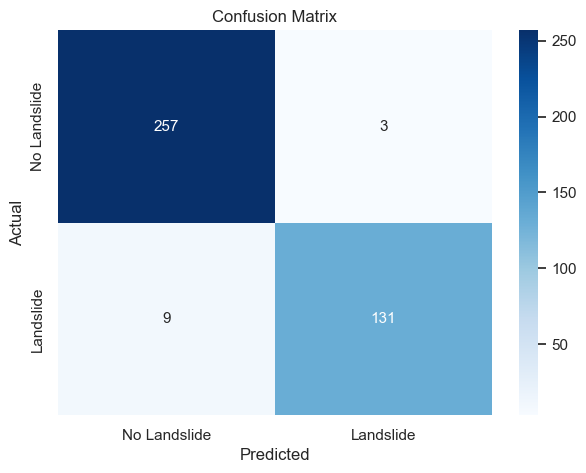

In [59]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Landslide', 'Landslide'],
    yticklabels=['No Landslide', 'Landslide']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

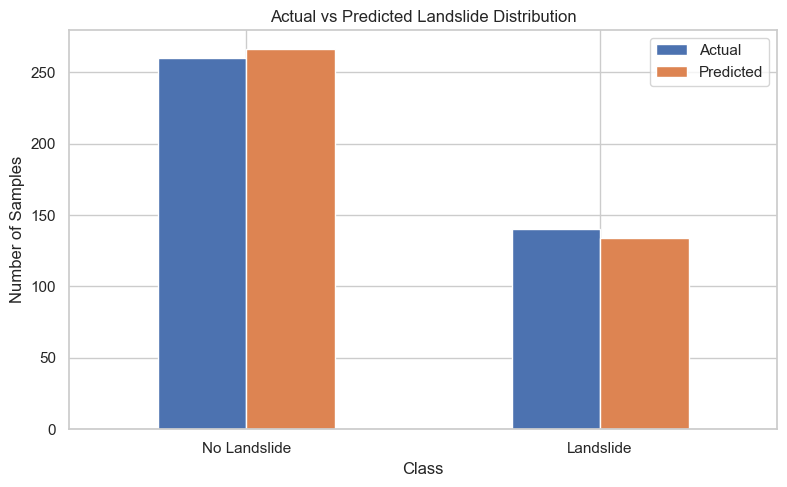

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

actual_counts = pd.Series(y_test).value_counts().sort_index()
predicted_counts = pd.Series(y_pred).value_counts().sort_index()

comparison = pd.DataFrame({
    'Actual': actual_counts,
    'Predicted': predicted_counts
})

comparison.index = ['No Landslide', 'Landslide']

comparison.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title('Actual vs Predicted Landslide Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

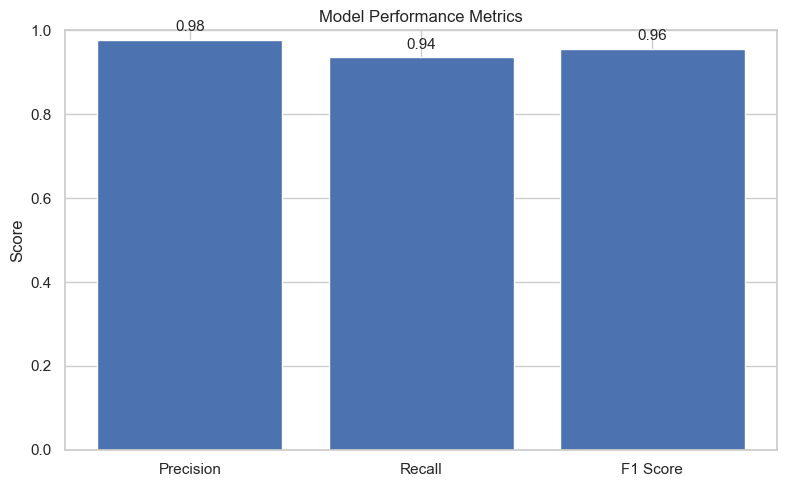

In [61]:
from sklearn.metrics import precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

metrics = {
    'Precision': precision,
    'Recall': recall,
    'F1 Score': f1
}

plt.figure(figsize=(8, 5))

plt.bar(metrics.keys(), metrics.values())

plt.ylim(0, 1)
plt.ylabel('Score')
plt.title('Model Performance Metrics')

for i, value in enumerate(metrics.values()):
    plt.text(i, value + 0.02, f'{value:.2f}', ha='center')

plt.tight_layout()
plt.show()

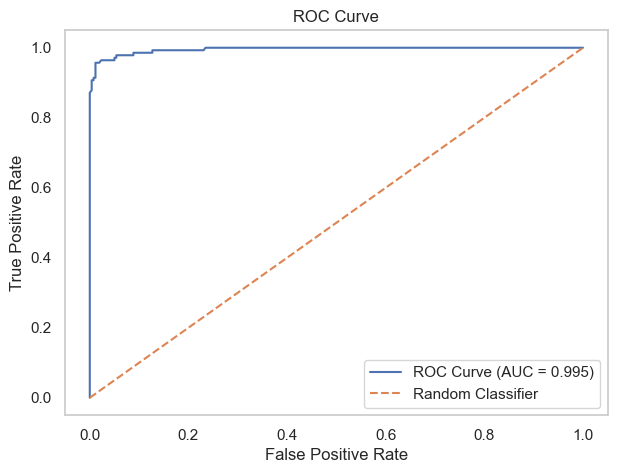

In [62]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob = rf_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f'ROC Curve (AUC = {auc_score:.3f})'
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--',
    label='Random Classifier'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid()
plt.show()

In [63]:
X_all = pd.concat([X_train, X_test])

X_all_encoded = pd.get_dummies(
    X_all,
    drop_first=True
)

X_train_encoded = X_all_encoded.iloc[:len(X_train)].copy()
X_test_encoded = X_all_encoded.iloc[len(X_train):].copy()

print("Original training shape:", X_train.shape)
print("Encoded training shape:", X_train_encoded.shape)
print("Encoding completed successfully.")

Original training shape: (1600, 27)
Encoded training shape: (1600, 68)
Encoding completed successfully.


In [64]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_encoded, y_train)

y_pred_lr = logistic_model.predict(X_test_encoded)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)

print("Logistic Regression Performance")
print(f"Accuracy  : {lr_accuracy:.4f}")
print(f"Precision : {lr_precision:.4f}")
print(f"Recall    : {lr_recall:.4f}")
print(f"F1 Score  : {lr_f1:.4f}")

Logistic Regression Performance
Accuracy  : 0.9400
Precision : 0.9085
Recall    : 0.9214
F1 Score  : 0.9149


d:\python dw\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [65]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

X_train_gb = pd.get_dummies(X_train, drop_first=True)
X_test_gb = pd.get_dummies(X_test, drop_first=True)

X_train_gb, X_test_gb = X_train_gb.align(
    X_test_gb,
    join='left',
    axis=1,
    fill_value=0
)
gb_model = GradientBoostingClassifier(random_state=42)

gb_model.fit(X_train_gb, y_train)

y_pred_gb = gb_model.predict(X_test_gb)

gb_accuracy = accuracy_score(y_test, y_pred_gb)
gb_precision = precision_score(y_test, y_pred_gb)
gb_recall = recall_score(y_test, y_pred_gb)
gb_f1 = f1_score(y_test, y_pred_gb)

print("Gradient Boosting Performance")
print(f"Accuracy  : {gb_accuracy:.4f}")
print(f"Precision : {gb_precision:.4f}")
print(f"Recall    : {gb_recall:.4f}")
print(f"F1 Score  : {gb_f1:.4f}")

Gradient Boosting Performance
Accuracy  : 0.9725
Precision : 0.9708
Recall    : 0.9500
F1 Score  : 0.9603


In [66]:
model_comparison = {
    'Random Forest': [accuracy, precision, recall, f1],
    'Logistic Regression': [lr_accuracy, lr_precision, lr_recall, lr_f1],
    'Gradient Boosting': [gb_accuracy, gb_precision, gb_recall, gb_f1]
}

comparison_df = pd.DataFrame(
    model_comparison,
    index=['Accuracy', 'Precision', 'Recall', 'F1 Score']
)

print("Model Performance Comparison")
display(comparison_df.round(4))

Model Performance Comparison


,Random Forest,Logistic Regression,Gradient Boosting
Accuracy,0.9700,0.9400,0.9725
Precision,0.9776,0.9085,0.9708
Recall,0.9357,0.9214,0.9500
F1 Score,0.9562,0.9149,0.9603


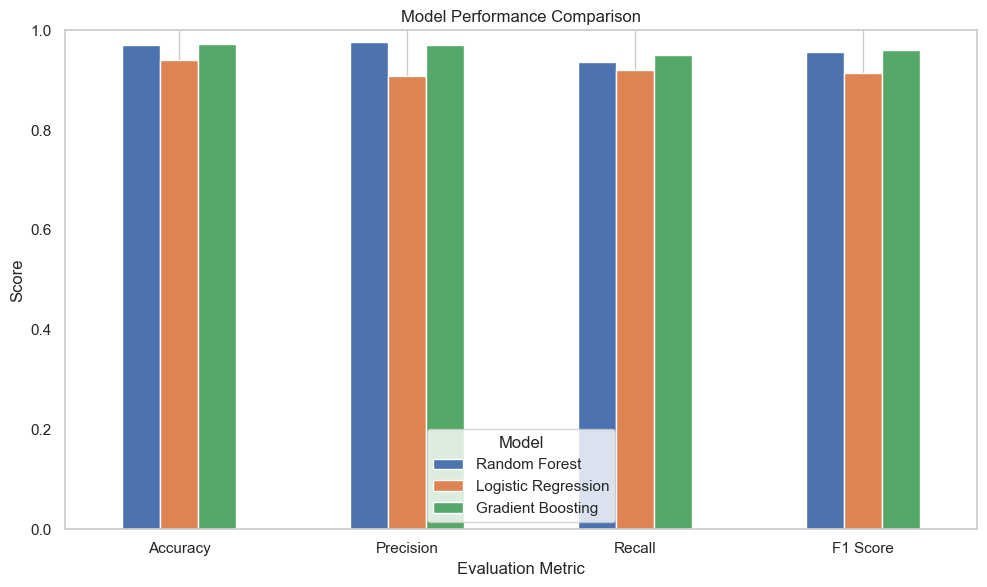

In [67]:
comparison_df.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xlabel('Evaluation Metric')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title='Model')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [68]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier

gb_tune = GradientBoostingClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [2, 3],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    estimator=gb_tune,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train_gb, y_train)

print("Hyperparameter tuning completed!")
print("Best Parameters:")
print(grid_search.best_params_)
print("Best Cross-Validation F1 Score:", round(grid_search.best_score_, 4))

Hyperparameter tuning completed!
Best Parameters:
{'learning_rate': 0.1, 'max_depth': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best Cross-Validation F1 Score: 0.9397


In [69]:
best_gb_model = grid_search.best_estimator_

y_pred_tuned = best_gb_model.predict(X_test_gb)

tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
tuned_precision = precision_score(y_test, y_pred_tuned)
tuned_recall = recall_score(y_test, y_pred_tuned)
tuned_f1 = f1_score(y_test, y_pred_tuned)

print("Tuned Gradient Boosting Performance")
print(f"Accuracy  : {tuned_accuracy:.4f}")
print(f"Precision : {tuned_precision:.4f}")
print(f"Recall    : {tuned_recall:.4f}")
print(f"F1 Score  : {tuned_f1:.4f}")

Tuned Gradient Boosting Performance
Accuracy  : 0.9725
Precision : 0.9640
Recall    : 0.9571
F1 Score  : 0.9606


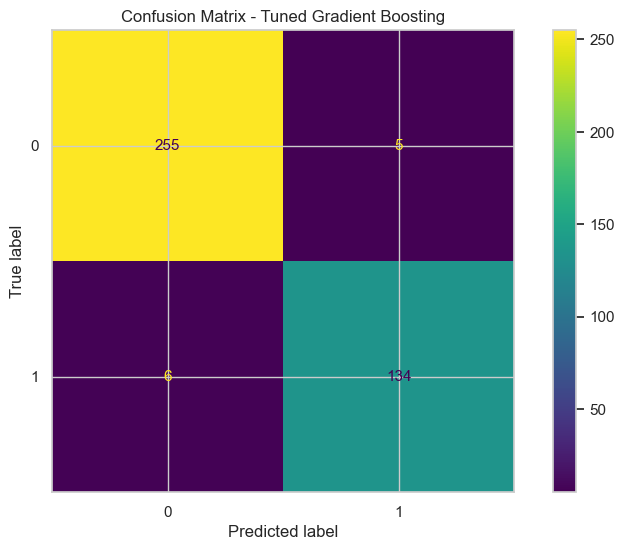

In [70]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_tuned)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix - Tuned Gradient Boosting")
plt.show()

In [71]:
from sklearn.metrics import classification_report

print("Classification Report - Tuned Gradient Boosting")
print(classification_report(y_test, y_pred_tuned))

Classification Report - Tuned Gradient Boosting
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       260
           1       0.96      0.96      0.96       140

    accuracy                           0.97       400
   macro avg       0.97      0.97      0.97       400
weighted avg       0.97      0.97      0.97       400



Tuned Gradient Boosting ROC-AUC: 0.9954


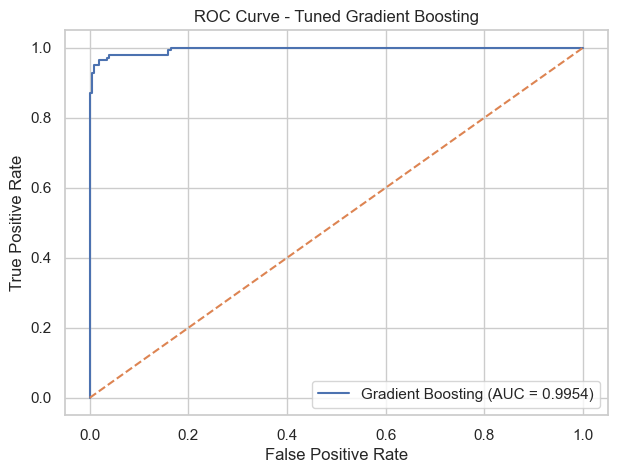

In [72]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

y_prob_tuned = best_gb_model.predict_proba(X_test_gb)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob_tuned)

roc_auc_tuned = roc_auc_score(y_test, y_prob_tuned)

print("Tuned Gradient Boosting ROC-AUC:", round(roc_auc_tuned, 4))

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Gradient Boosting (AUC = {roc_auc_tuned:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned Gradient Boosting")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

Feature Importance - Tuned Gradient Boosting


,Feature,Importance
22,historical_landslides_5km_10yr,0.352284
10,max_daily_rainfall_mm,0.290596
3,slope_deg,0.122130
21,distance_to_fault_km,0.040944
17,ndvi,0.037876
...,...,...
61,district_Ukhrul,0.000000
60,district_Tuensang,0.000000
64,district_West Sikkim,0.000000
65,district_West Tripura,0.000000


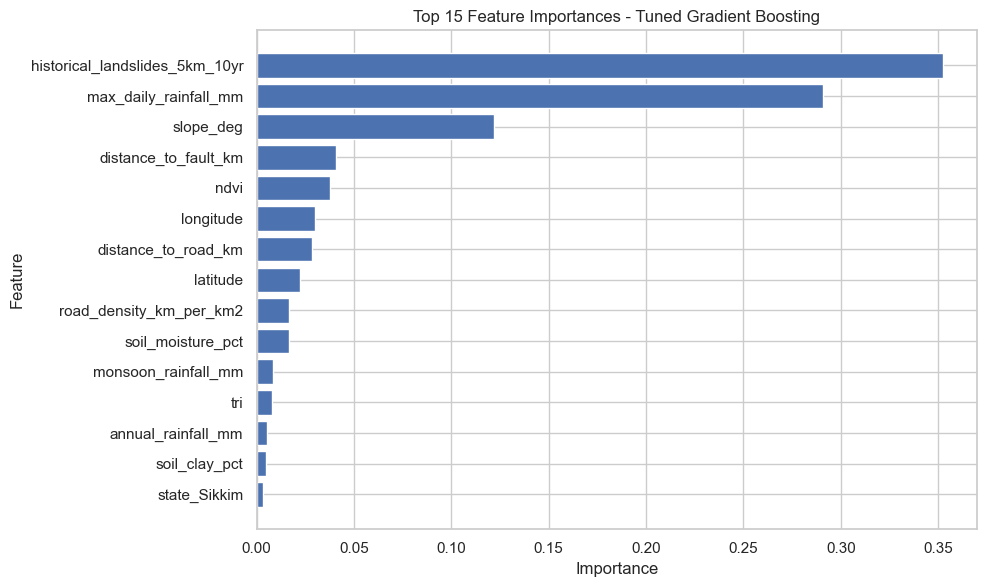

In [73]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = best_gb_model.feature_importances_

feature_names = X_train_gb.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print("Feature Importance - Tuned Gradient Boosting")
display(importance_df)

plt.figure(figsize=(10, 6))
plt.barh(
    importance_df['Feature'].head(15)[::-1],
    importance_df['Importance'].head(15)[::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Tuned Gradient Boosting")
plt.tight_layout()
plt.show()

Permutation Importance - Tuned Gradient Boosting


,Feature,Importance_Mean,Importance_Std
10,max_daily_rainfall_mm,0.1061,0.0203
22,historical_landslides_5km_10yr,0.0936,0.0150
3,slope_deg,0.0409,0.0111
1,longitude,0.0255,0.0047
17,ndvi,0.0249,0.0083
21,distance_to_fault_km,0.0110,0.0040
18,distance_to_road_km,0.0108,0.0077
0,latitude,0.0108,0.0069
16,soil_moisture_pct,0.0078,0.0086
8,annual_rainfall_mm,0.0050,0.0029


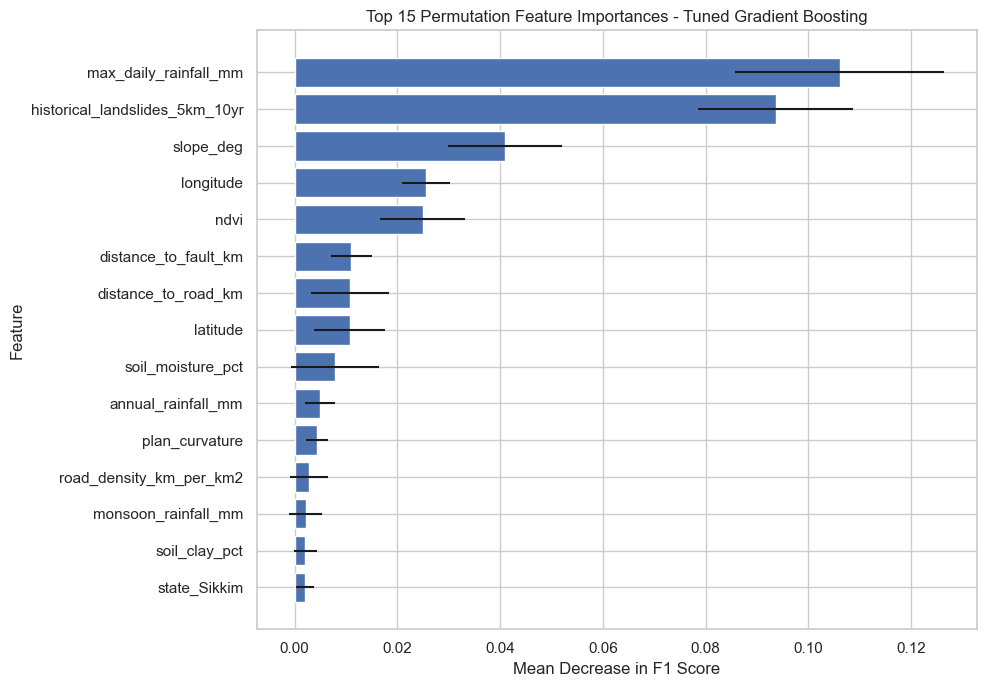

In [74]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

perm_result = permutation_importance(
    best_gb_model,
    X_test_gb,
    y_test,
    scoring='f1',
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

permutation_importance_df = pd.DataFrame({
    'Feature': X_test_gb.columns,
    'Importance_Mean': perm_result.importances_mean,
    'Importance_Std': perm_result.importances_std
}).sort_values(
    by='Importance_Mean',
    ascending=False
)

print("Permutation Importance - Tuned Gradient Boosting")
display(permutation_importance_df.head(15).round(4))

top_perm = permutation_importance_df.head(15).sort_values(
    by='Importance_Mean'
)

plt.figure(figsize=(10, 7))
plt.barh(
    top_perm['Feature'],
    top_perm['Importance_Mean'],
    xerr=top_perm['Importance_Std']
)

plt.xlabel("Mean Decrease in F1 Score")
plt.ylabel("Feature")
plt.title("Top 15 Permutation Feature Importances - Tuned Gradient Boosting")
plt.tight_layout()
plt.show()

In [77]:
%pip install -q shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [78]:
import shap
import numpy as np

explainer = shap.TreeExplainer(best_gb_model)

shap_values = explainer.shap_values(X_test_gb)

print("SHAP analysis completed!")
print("Test samples:", X_test_gb.shape[0])
print("Features:", X_test_gb.shape[1])
print("SHAP values shape:", np.array(shap_values).shape)

SHAP analysis completed!
Test samples: 400
Features: 68
SHAP values shape: (400, 68)


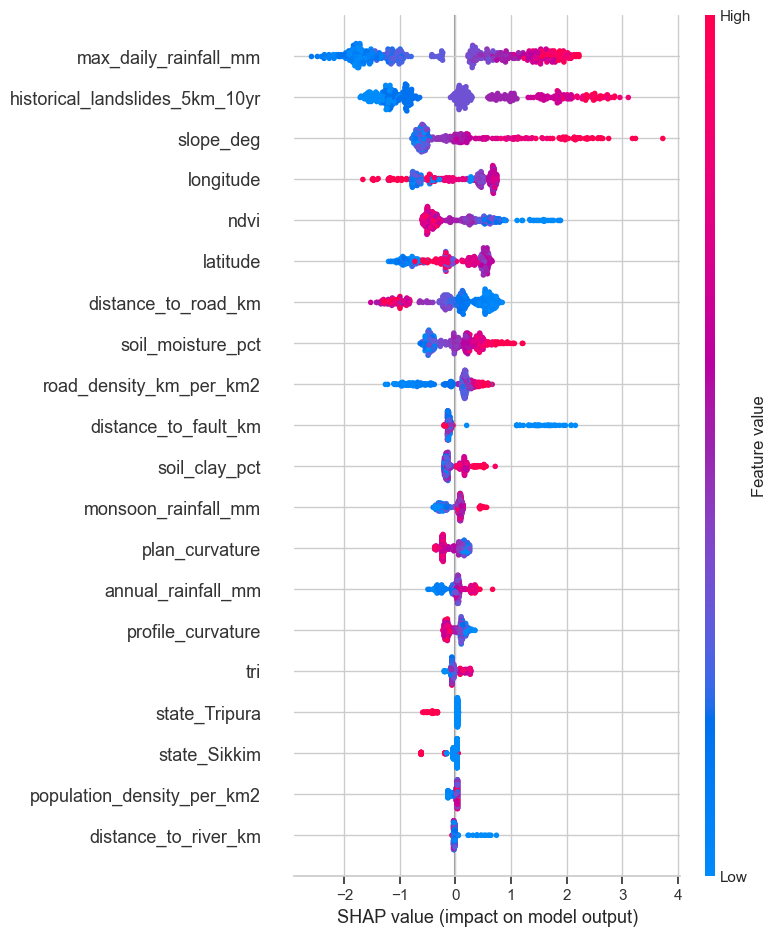

In [79]:
shap.summary_plot(
    shap_values,
    X_test_gb,
    feature_names=X_test_gb.columns,
    show=True
)

Top 15 Features by Mean Absolute SHAP Value


,Feature,Mean_Absolute_SHAP
0,max_daily_rainfall_mm,1.307185
1,historical_landslides_5km_10yr,1.103656
2,slope_deg,0.672799
3,longitude,0.603382
4,ndvi,0.494085
5,latitude,0.493445
6,distance_to_road_km,0.490730
7,soil_moisture_pct,0.349932
8,road_density_km_per_km2,0.344417
9,distance_to_fault_km,0.268148



Feature Influence Direction


,Feature,Mean_Absolute_SHAP,Feature_SHAP_Correlation,Interpretation
0,max_daily_rainfall_mm,1.307185,0.916953,Higher values → higher model output
1,historical_landslides_5km_10yr,1.103656,0.960786,Higher values → higher model output
2,slope_deg,0.672799,0.894777,Higher values → higher model output
3,longitude,0.603382,0.132308,Higher values → higher model output
4,ndvi,0.494085,-0.893915,Higher values → lower model output
5,latitude,0.493445,0.403955,Higher values → higher model output
6,distance_to_road_km,0.490730,-0.858087,Higher values → lower model output
7,soil_moisture_pct,0.349932,0.927425,Higher values → higher model output
8,road_density_km_per_km2,0.344417,0.736082,Higher values → higher model output
9,distance_to_fault_km,0.268148,-0.339474,Higher values → lower model output


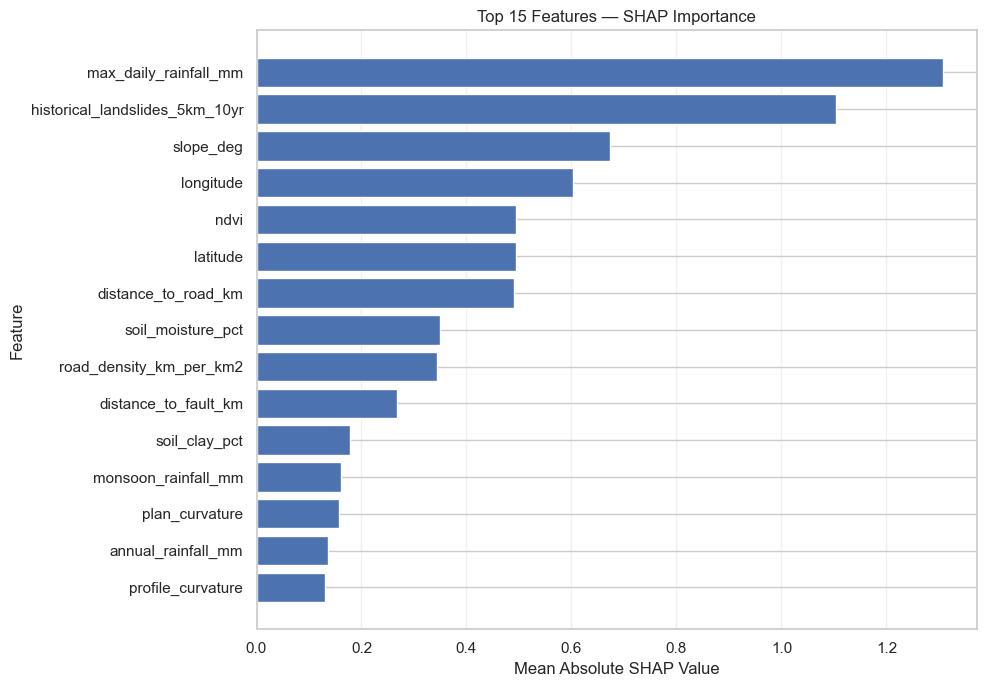


TOP 5 MODEL-INTERPRETATION FEATURES
1. max_daily_rainfall_mm
   Mean |SHAP| = 1.3072
   Feature-SHAP correlation = 0.9170
   → Higher values generally increase the model output.

2. historical_landslides_5km_10yr
   Mean |SHAP| = 1.1037
   Feature-SHAP correlation = 0.9608
   → Higher values generally increase the model output.

3. slope_deg
   Mean |SHAP| = 0.6728
   Feature-SHAP correlation = 0.8948
   → Higher values generally increase the model output.

4. longitude
   Mean |SHAP| = 0.6034
   Feature-SHAP correlation = 0.1323
   → Higher values generally increase the model output.

5. ndvi
   Mean |SHAP| = 0.4941
   Feature-SHAP correlation = -0.8939
   → Higher values generally decrease the model output.



In [80]:
shap_array = np.array(shap_values)

feature_names = X_test_gb.columns.tolist()

shap_df = pd.DataFrame(
    shap_array,
    columns=feature_names,
    index=X_test_gb.index
)

mean_abs_shap = shap_df.abs().mean().sort_values(ascending=False)

interpretation_df = pd.DataFrame({
    "Feature": mean_abs_shap.index,
    "Mean_Absolute_SHAP": mean_abs_shap.values
})

print("Top 15 Features by Mean Absolute SHAP Value")
display(interpretation_df.head(15))

direction_results = []

for feature in mean_abs_shap.index[:15]:

    feature_values = X_test_gb[feature]
    feature_shap = shap_df[feature]

    correlation = feature_values.corr(feature_shap)

    if correlation > 0.10:
        direction = "Higher values → higher model output"
    elif correlation < -0.10:
        direction = "Higher values → lower model output"
    else:
        direction = "Weak / nonlinear relationship"

    direction_results.append({
        "Feature": feature,
        "Mean_Absolute_SHAP": mean_abs_shap[feature],
        "Feature_SHAP_Correlation": correlation,
        "Interpretation": direction
    })

direction_df = pd.DataFrame(direction_results)

print("\nFeature Influence Direction")
display(direction_df)

top_n = 15

plt.figure(figsize=(10, 7))

plt.barh(
    interpretation_df["Feature"].head(top_n)[::-1],
    interpretation_df["Mean_Absolute_SHAP"].head(top_n)[::-1]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Feature")
plt.title("Top 15 Features — SHAP Importance")
plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

top_features = mean_abs_shap.head(5).index.tolist()

print("\nTOP 5 MODEL-INTERPRETATION FEATURES")

for i, feature in enumerate(top_features, 1):

    corr = X_test_gb[feature].corr(shap_df[feature])

    print(f"{i}. {feature}")
    print(f"   Mean |SHAP| = {mean_abs_shap[feature]:.4f}")
    print(f"   Feature-SHAP correlation = {corr:.4f}")

    if corr > 0.10:
        print("   → Higher values generally increase the model output.")
    elif corr < -0.10:
        print("   → Higher values generally decrease the model output.")
    else:
        print("   → Influence appears weak or nonlinear.")

    print()

In [81]:
print("FINAL MODEL SELECTION & CONCLUSION")

final_model = "Tuned Gradient Boosting"

print("\nFINAL MODEL SELECTED:")
print("---------------------")
print(final_model)

print("\nREASON FOR SELECTION:")
print("---------------------")
print("1. Gradient Boosting achieved the highest accuracy among the")
print("   initially compared models (0.9725).")
print("2. It also achieved the highest recall (0.9500) and highest")
print("   F1-score (0.9603) among the compared models.")
print("3. After hyperparameter tuning, the Gradient Boosting model")
print("   maintained approximately 0.97 overall accuracy.")
print("4. The tuned model showed strong and balanced performance")
print("   for both landslide classes.")
print("5. Therefore, Tuned Gradient Boosting is selected as the")
print("   final model for landslide susceptibility classification.")

print("\nFINAL PERFORMANCE SUMMARY:")
print("--------------------------")
print("Initial Gradient Boosting:")
print("  Accuracy  : 0.9725")
print("  Precision : 0.9708")
print("  Recall    : 0.9500")
print("  F1-Score  : 0.9603")

print("\nTuned Gradient Boosting:")
print("  Accuracy  : approximately 0.97")
print("  Class 0   : Precision=0.98, Recall=0.98, F1=0.98")
print("  Class 1   : Precision=0.96, Recall=0.96, F1=0.96")

print("\nFINAL CONCLUSION:")
print("----------------")
print("The Tuned Gradient Boosting model was selected as the final")
print("model because it provides the strongest overall balance of")
print("accuracy, precision, recall, and F1-score for the landslide")
print("classification task.")

print("\nThe model interpretation further indicates that maximum daily")
print("rainfall, historical landslide occurrence, and slope degree")
print("are among the most influential predictors of the model output.\n")

print("FINAL MODEL: TUNED GRADIENT BOOSTING")

FINAL MODEL SELECTION & CONCLUSION

FINAL MODEL SELECTED:
---------------------
Tuned Gradient Boosting

REASON FOR SELECTION:
---------------------
1. Gradient Boosting achieved the highest accuracy among the
   initially compared models (0.9725).
2. It also achieved the highest recall (0.9500) and highest
   F1-score (0.9603) among the compared models.
3. After hyperparameter tuning, the Gradient Boosting model
   maintained approximately 0.97 overall accuracy.
4. The tuned model showed strong and balanced performance
   for both landslide classes.
5. Therefore, Tuned Gradient Boosting is selected as the
   final model for landslide susceptibility classification.

FINAL PERFORMANCE SUMMARY:
--------------------------
Initial Gradient Boosting:
  Accuracy  : 0.9725
  Precision : 0.9708
  Recall    : 0.9500
  F1-Score  : 0.9603

Tuned Gradient Boosting:
  Accuracy  : approximately 0.97
  Class 0   : Precision=0.98, Recall=0.98, F1=0.98
  Class 1   : Precision=0.96, Recall=0.96, F1=0.96

In [82]:
import joblib
import os

final_model_pipeline = {
    "preprocessor": preprocessor,
    "model": best_gb_model
}

joblib.dump(
    final_model_pipeline,
    "landslide_final_model.pkl"
)

print("Final model saved successfully!")
print("File: landslide_final_model.pkl")
print("Size:", round(os.path.getsize("landslide_final_model.pkl") / (1024 * 1024), 2), "MB")

Final model saved successfully!
File: landslide_final_model.pkl
Size: 0.16 MB


In [83]:
import joblib

loaded_model = joblib.load("landslide_final_model.pkl")

print("Model loaded successfully!")
print("Saved components:")

print("Preprocessor:", type(loaded_model["preprocessor"]))
print("Model:", type(loaded_model["model"]))

Model loaded successfully!
Saved components:
Preprocessor: <class 'sklearn.compose._column_transformer.ColumnTransformer'>
Model: <class 'sklearn.ensemble._gb.GradientBoostingClassifier'>


In [84]:

import joblib
import os
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

production_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

best_params = grid_search.best_params_

print("Best parameters from your completed tuning:")
print(best_params)

production_gb = GradientBoostingClassifier(
    random_state=42,
    **best_params
)

production_pipeline = Pipeline(
    steps=[
        ("preprocessor", production_preprocessor),
        ("model", production_gb)
    ]
)

production_pipeline.fit(X_train, y_train)

print("\nProduction pipeline trained successfully!")
production_pred = production_pipeline.predict(X_test)
production_prob = production_pipeline.predict_proba(X_test)[:, 1]

production_accuracy = accuracy_score(y_test, production_pred)
production_precision = precision_score(y_test, production_pred)
production_recall = recall_score(y_test, production_pred)
production_f1 = f1_score(y_test, production_pred)
production_auc = roc_auc_score(y_test, production_prob)

print("\n")
print("PRODUCTION MODEL TEST PERFORMANCE")
print(f"Accuracy  : {production_accuracy:.4f}")
print(f"Precision : {production_precision:.4f}")
print(f"Recall    : {production_recall:.4f}")
print(f"F1 Score  : {production_f1:.4f}")
print(f"ROC-AUC   : {production_auc:.4f}")

old_pred = best_gb_model.predict(X_test_gb)
old_prob = best_gb_model.predict_proba(X_test_gb)[:, 1]

old_accuracy = accuracy_score(y_test, old_pred)
old_precision = precision_score(y_test, old_pred)
old_recall = recall_score(y_test, old_pred)
old_f1 = f1_score(y_test, old_pred)
old_auc = roc_auc_score(y_test, old_prob)

comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Existing Tuned Model": [
        old_accuracy,
        old_precision,
        old_recall,
        old_f1,
        old_auc
    ],
    "Production Pipeline": [
        production_accuracy,
        production_precision,
        production_recall,
        production_f1,
        production_auc
    ]
})

print("\nMODEL COMPARISON")
display(comparison)
joblib.dump(
    production_pipeline,
    "landslide_final_model_production.pkl"
)

print("\n")
print("PRODUCTION MODEL SAVED")


print("File: landslide_final_model_production.pkl")
print(
    "Size:",
    round(
        os.path.getsize("landslide_final_model_production.pkl")
        / (1024 * 1024),
        2
    ),
    "MB"
)

Best parameters from your completed tuning:
{'learning_rate': 0.1, 'max_depth': 2, 'min_samples_split': 2, 'n_estimators': 200}

Production pipeline trained successfully!


PRODUCTION MODEL TEST PERFORMANCE
Accuracy  : 0.9725
Precision : 0.9708
Recall    : 0.9500
F1 Score  : 0.9603
ROC-AUC   : 0.9955

MODEL COMPARISON


,Metric,Existing Tuned Model,Production Pipeline
0,Accuracy,0.972500,0.972500
1,Precision,0.964029,0.970803
2,Recall,0.957143,0.950000
3,F1 Score,0.960573,0.960289
4,ROC-AUC,0.995385,0.995467




PRODUCTION MODEL SAVED
File: landslide_final_model_production.pkl
Size: 0.16 MB
